In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [4]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
data["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

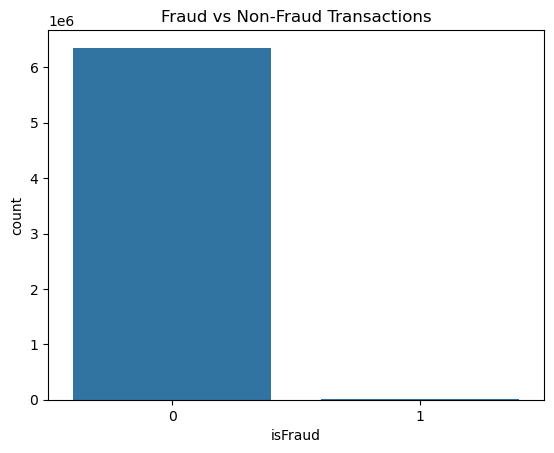

In [8]:
sns.countplot(x="isFraud", data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [9]:
data["type"].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [10]:
data["type"] = data["type"].map({
    "PAYMENT":0,
    "TRANSFER":1,
    "CASH_OUT":2,
    "DEBIT":3,
    "CASH_IN":4
})

In [11]:
x = data[["type","amount","oldbalanceOrg","newbalanceOrig"]]

y = data["isFraud"]

In [12]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(xtrain, ytrain)

DecisionTreeClassifier()

In [14]:
print(model.score(xtest, ytest))

0.9997351719888976


In [16]:
features = pd.DataFrame([[2, 5000, 20000, 15000]],
columns=["type","amount","oldbalanceOrg","newbalanceOrig"])

print(model.predict(features))

[0]


In [17]:
from sklearn.metrics import confusion_matrix, classification_report

In [18]:
ypred = model.predict(xtest)

In [19]:
cm = confusion_matrix(ytest, ypred)

print(cm)

[[1270736     168]
 [    169    1451]]


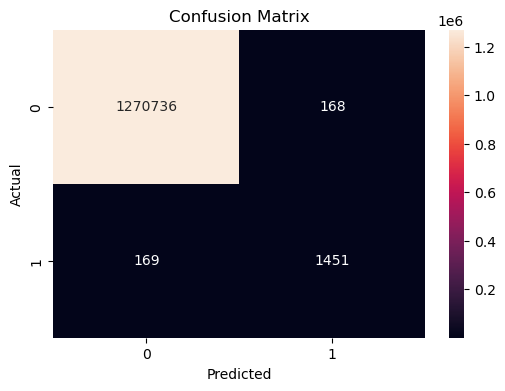

In [20]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.90      0.90      0.90      1620

    accuracy                           1.00   1272524
   macro avg       0.95      0.95      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524



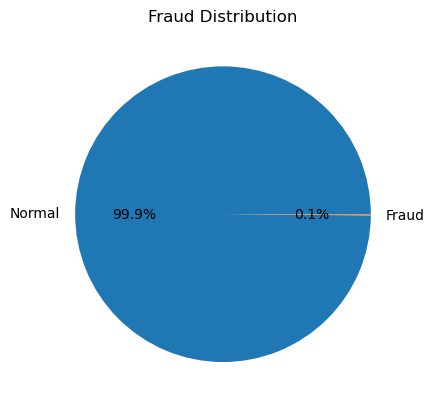

In [22]:
fraud = data["isFraud"].value_counts()

plt.pie(fraud, labels=["Normal","Fraud"], autopct='%1.1f%%')

plt.title("Fraud Distribution")

plt.show()